In [12]:
# import cudf # Library RAPIDS untuk pengganti Pandas (GPU)
# import io

# 1. Load dataset (path bisa dilihat di bagian 'Input' sebelah kanan)
# path = '/kaggle/input/nama-dataset-kamu/accepted_2260701.csv'
# df = cudf.read_csv(path)

# 2. EDA Cepat: Cek Missing Values di SEMUA 151 kolom
# missing_data = df.isnull().sum()
# print(missing_data[missing_data > 0]) # Hanya tampilkan kolom yang ada bolongnya

# 3. Feature Reduction: Buang kolom yang data kosongnya > 50%
# threshold = len(df) * 0.5
# cols_to_keep = missing_data[missing_data < threshold].index
# df_clean = df[cols_to_keep]

# print(f"Sisa kolom setelah filter: {len(df_clean.columns)}")

# Cell 1 — Cek Path Dataset

In [13]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shaneformethan/ppti-20-data-mining-kelompok-1/accepted_2007_to_2018Q4.csv
/kaggle/input/datasets/shaneformethan/ppti-20-data-mining-kelompok-1/rejected_2007_to_2018Q4.csv


# Cell 2 — Load Data

In [14]:
import pandas as pd
import numpy as np

path = '/kaggle/input/datasets/shaneformethan/ppti-20-data-mining-kelompok-1/accepted_2007_to_2018Q4.csv'  # ganti sesuai hasil Cell 1
df = pd.read_csv(path, low_memory=False)
print(df.shape)

(2260701, 151)


# Phase 1

## Cell 3 — Eksplorasi Awal

In [15]:
# Missing values overview (dataset mentah)
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_pct
member_id,2260701,100.00
orig_projected_additional_accrued_interest,2252050,99.62
hardship_reason,2249784,99.52
hardship_payoff_balance_amount,2249784,99.52
hardship_last_payment_amount,2249784,99.52
...,...,...
total_rec_late_fee,33,0.00
total_rec_int,33,0.00
disbursement_method,33,0.00
hardship_flag,33,0.00


In [16]:
df.dtypes.value_counts()

float64    113
object      38
Name: count, dtype: int64

In [17]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.00,20000.0000,40000.00
funded_amnt,2260668.0,15041.664057,9188.413022,500.00,8000.00,12875.00,20000.0000,40000.00
funded_amnt_inv,2260668.0,15023.437745,9192.331679,0.00,8000.00,12800.00,20000.0000,40000.00
int_rate,2260668.0,13.092829,4.832138,5.31,9.49,12.62,15.9900,30.99
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,10917.0,11636.883942,7625.988281,55.73,5627.00,10028.39,16151.8900,40306.41
hardship_last_payment_amount,10917.0,193.994321,198.629496,0.01,44.44,133.16,284.1900,1407.86
settlement_amount,34246.0,5010.664267,3693.122590,44.21,2208.00,4146.11,6850.1725,33601.00
settlement_percentage,34246.0,47.780365,7.311822,0.20,45.00,45.00,50.0000,521.35


In [18]:
df.describe(include=['object']).T

,count,unique,top,freq
id,2260701,2260701,Total amount funded in policy code 2: 521953170,1
term,2260668,2,36 months,1609754
grade,2260668,7,B,663557
sub_grade,2260668,35,C1,145903
emp_title,2093699,512694,Teacher,38824
emp_length,2113761,11,10+ years,748005
home_ownership,2260668,6,MORTGAGE,1111450
verification_status,2260668,3,Source Verified,886231
issue_d,2260668,139,Mar-2016,61992
loan_status,2260668,9,Fully Paid,1076751


## Cell 4 — Seleksi Kolom Awal (domain reasoning)

In [19]:
selected_cols = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'issue_d', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line',
    'fico_range_low', 'fico_range_high', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
    'pub_rec_bankruptcies', 'application_type', 'loan_status'
]
df_selected = df[selected_cols].copy()
print(df_selected.shape)

(2260701, 26)


## Cell 5 — Data Cleaning

In [20]:
# Cek & hapus duplikat
print("Duplikat:", df_selected.duplicated().sum())
df_selected = df_selected.drop_duplicates()

# Bersihkan format string
df_selected['term'] = df_selected['term'].str.strip().str.replace(' months', '').astype(float)

emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10
}
df_selected['emp_length_num'] = df_selected['emp_length'].map(emp_map)

Duplikat: 32


In [21]:
# Cek missing pada kolom terpilih
missing_selected = df_selected.isnull().mean().sort_values(ascending=False) * 100
print(missing_selected)

emp_length              6.498430
emp_length_num          6.498430
mort_acc                2.213106
revol_util              0.079755
dti                     0.075730
pub_rec_bankruptcies    0.060425
delinq_2yrs             0.001327
pub_rec                 0.001327
earliest_cr_line        0.001327
open_acc                0.001327
total_acc               0.001327
annual_inc              0.000221
issue_d                 0.000044
home_ownership          0.000044
sub_grade               0.000044
installment             0.000044
grade                   0.000044
term                    0.000044
int_rate                0.000044
loan_amnt               0.000044
verification_status     0.000044
purpose                 0.000044
fico_range_high         0.000044
fico_range_low          0.000044
revol_bal               0.000044
application_type        0.000044
loan_status             0.000044
dtype: float64


In [22]:
# Imputasi
num_cols = df_selected.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df_selected[col] = df_selected[col].fillna(df_selected[col].median())

cat_cols = df_selected.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_selected[col] = df_selected[col].fillna('Unknown')

print(df_selected.isnull().sum().sum(), "missing tersisa")

0 missing tersisa


## Cell 6 — Outlier Check (laporan untuk dipakai lagi di Phase 4)

In [23]:
def iqr_outlier_report(df, cols):
    report = {}
    for col in cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        report[col] = ((df[col] < lower) | (df[col] > upper)).sum()
    return pd.Series(report).sort_values(ascending=False)

iqr_outlier_report(df_selected, ['loan_amnt', 'annual_inc', 'dti', 'revol_bal', 'int_rate'])

revol_bal     137095
annual_inc    110041
int_rate       41099
loan_amnt      35215
dti            21633
dtype: int64

## Cell 7 — Correlation Analysis

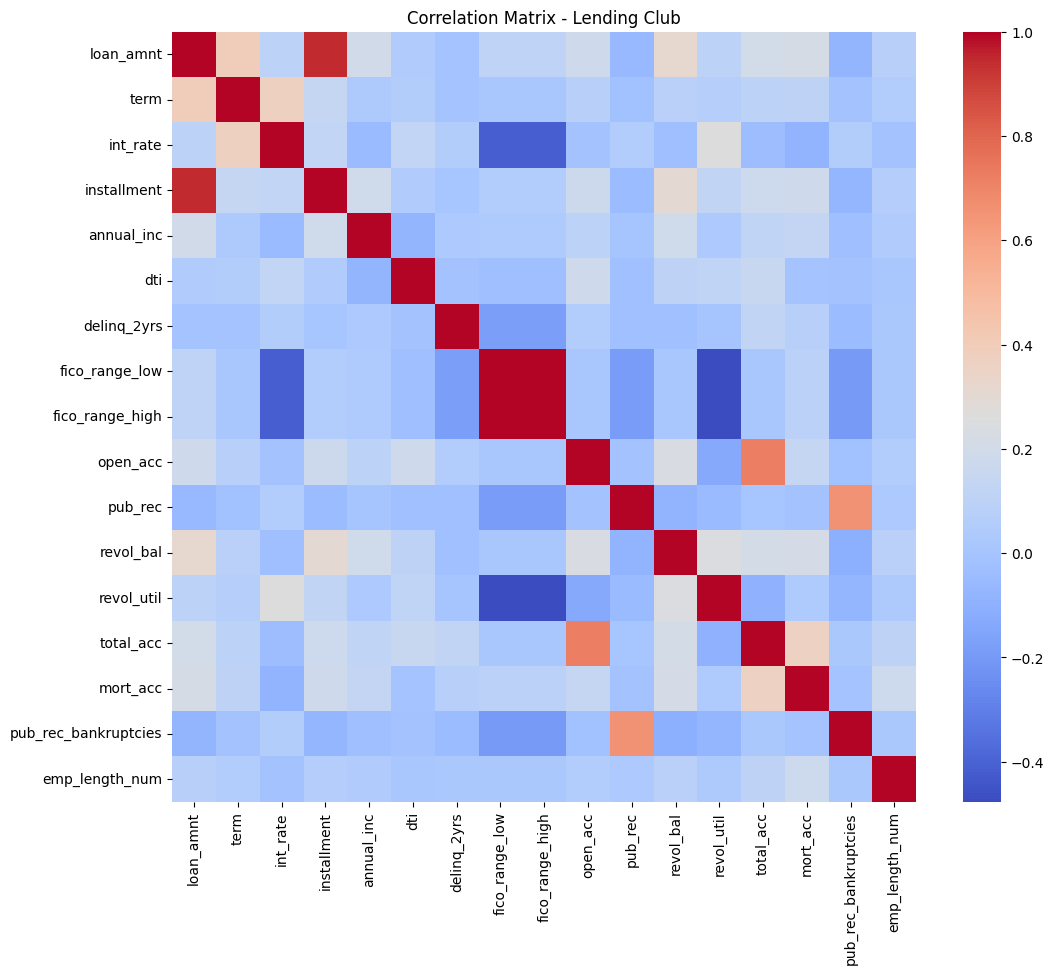

fico_range_high  fico_range_low     1.000000
fico_range_low   fico_range_high    1.000000
loan_amnt        installment        0.945625
installment      loan_amnt          0.945625
dtype: float64


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_selected[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix - Lending Club")
plt.show()

high_corr = corr.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr < 1.0) & (high_corr > 0.85)]
print(high_corr)

## Cell 8 — Entropy Analysis

In [25]:
from scipy.stats import entropy

def feature_entropy(series):
    probs = series.value_counts(normalize=True)
    return entropy(probs, base=2)

for col in cat_cols:
    print(f"{col}: entropy = {feature_entropy(df_selected[col]):.3f}")

grade: entropy = 2.285
sub_grade: entropy = 4.595
emp_length: entropy = 3.189
home_ownership: entropy = 1.393
verification_status: entropy = 1.571
issue_d: entropy = 6.252
purpose: entropy = 1.964
earliest_cr_line: entropy = 8.467
application_type: entropy = 0.301
loan_status: entropy = 1.529


## Cell 9 — Finalisasi Feature Set

In [26]:
# Gabung fico_low/high, simpan loan_status terpisah
df_selected['fico_score'] = (df_selected['fico_range_low'] + df_selected['fico_range_high']) / 2
loan_status_reference = df_selected['loan_status'].copy()

cols_to_drop = [
    'fico_range_low', 'fico_range_high',
    'installment',
    'application_type',
    'emp_length',
    'loan_status'
]
df_final = df_selected.drop(columns=cols_to_drop)
print(df_final.shape)

(2260669, 22)


## Cell 10 — Sanity Check Korelasi Ulang

In [27]:
num_cols_final = df_final.select_dtypes(include=[np.number]).columns
corr_final = df_final[num_cols_final].corr()
high_corr_final = corr_final.abs().unstack().sort_values(ascending=False)
high_corr_final = high_corr_final[(high_corr_final < 1.0) & (high_corr_final > 0.85)]
print(high_corr_final)  # harusnya kosong

Series([], dtype: float64)


## Cell 11 — Transformasi Tanggal

In [28]:
# 1. Parsing tanggal, nilai yg gagal (misal 'Unknown') jadi NaT, bukan error
df_final['issue_d'] = pd.to_datetime(df_final['issue_d'], format='%b-%Y', errors='coerce')
df_final['earliest_cr_line'] = pd.to_datetime(df_final['earliest_cr_line'], format='%b-%Y', errors='coerce')

# 2. Cek dulu berapa banyak yang jadi NaT (agar tahu skala masalahnya)
print("issue_d NaT:", df_final['issue_d'].isna().sum())
print("earliest_cr_line NaT:", df_final['earliest_cr_line'].isna().sum())

# 3. Hitung credit_history_years (otomatis NaN kalau salah satu tanggal NaT)
df_final['credit_history_years'] = (
    (df_final['issue_d'] - df_final['earliest_cr_line']).dt.days / 365.25
).round(2)

# 4. issue_year, isi NaN dgn tahun paling umum (modus) sbg fallback wajar
df_final['issue_year'] = df_final['issue_d'].dt.year
df_final['issue_year'] = df_final['issue_year'].fillna(df_final['issue_year'].mode()[0])

# 5. credit_history_years, isi NaN dgn median (konsisten dgn strategi imputasi numerik sebelumnya)
median_credit_history = df_final['credit_history_years'].median()
df_final['credit_history_years'] = df_final['credit_history_years'].fillna(median_credit_history)

# 6. Drop kolom tanggal mentah
df_final = df_final.drop(columns=['issue_d', 'earliest_cr_line'])

print(df_final[['credit_history_years', 'issue_year']].describe())

issue_d NaT: 1
earliest_cr_line NaT: 30
       credit_history_years    issue_year
count          2.260669e+06  2.260669e+06
mean           1.639459e+01  2.015858e+03
std            7.679677e+00  1.792634e+00
min            5.000000e-01  2.007000e+03
25%            1.125000e+01  2.015000e+03
50%            1.483000e+01  2.016000e+03
75%            2.025000e+01  2.017000e+03
max            8.325000e+01  2.018000e+03


## Cell 12 — Cek Kategori Tersisa

In [29]:
cat_cols_final = df_final.select_dtypes(include=['object']).columns
for col in cat_cols_final:
    print(f"{col}: {df_final[col].nunique()} kategori unik")

grade: 8 kategori unik
sub_grade: 36 kategori unik
home_ownership: 7 kategori unik
verification_status: 4 kategori unik
purpose: 15 kategori unik


## Cell 13 — Encoding

In [30]:
df_encoded = df_final.copy()

grade_order = ['A','B','C','D','E','F','G']
df_encoded['grade_num'] = df_encoded['grade'].apply(
    lambda x: grade_order.index(x) if x in grade_order else -1
)

def encode_subgrade(sg):
    if sg in ['Unknown', None] or pd.isna(sg):
        return -1
    try:
        g, n = sg[0], int(sg[1])
        return grade_order.index(g) * 5 + n
    except:
        return -1

df_encoded['sub_grade_num'] = df_encoded['sub_grade'].apply(encode_subgrade)

nominal_cols = ['home_ownership', 'verification_status', 'purpose']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True)

print(df_encoded.shape)

(2260669, 44)


## Cell 14 — Binning (untuk Phase 3 nanti)

In [31]:
# Perbaikan 1: annual_inc bin - ubah batas bawah jadi -0.01 agar annual_inc=0 tertangkap
df_encoded['annual_inc_bin'] = pd.cut(df_encoded['annual_inc'],
    bins=[-0.01, 40000, 70000, 100000, 150000, np.inf],
    labels=['<40K', '40-70K', '70-100K', '100-150K', '150K+'])

# Perbaikan 2: dti bin - perluas batas bawah ke -inf untuk tangkap nilai sentinel/ekstrem negatif
df_encoded['dti_bin'] = pd.cut(df_encoded['dti'],
    bins=[-np.inf, 10, 20, 30, np.inf],
    labels=['Low(<10)', 'Moderate(10-20)', 'High(20-30)', 'VeryHigh(30+)'])

df_encoded['fico_bin'] = pd.cut(df_encoded['fico_score'],
    bins=[0, 580, 670, 740, 800, 850],
    labels=['Poor', 'Fair', 'Good', 'VeryGood', 'Excellent'])

df_encoded['loan_amnt_bin'] = pd.cut(df_encoded['loan_amnt'],
    bins=[0, 5000, 15000, 25000, np.inf],
    labels=['Small', 'Medium', 'Large', 'VeryLarge'])

# Verifikasi ulang: pastikan tidak ada NaN tersisa
print("Missing di kolom bin setelah perbaikan:")
print(df_encoded[['annual_inc_bin','dti_bin','fico_bin','loan_amnt_bin']].isnull().sum())

Missing di kolom bin setelah perbaikan:
annual_inc_bin    0
dti_bin           0
fico_bin          0
loan_amnt_bin     0
dtype: int64


## Cell 15 — Cek Skewness

In [32]:
numeric_for_clustering = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 
                           'fico_score', 'revol_bal', 'revol_util', 
                           'total_acc', 'open_acc', 'mort_acc', 
                           'emp_length_num', 'credit_history_years']

skewness = df_encoded[numeric_for_clustering].skew().sort_values(ascending=False)
print(skewness)

annual_inc              493.886614
dti                      29.212916
revol_bal                13.231991
mort_acc                  1.823718
open_acc                  1.315558
fico_score                1.192997
credit_history_years      1.074521
total_acc                 1.007469
loan_amnt                 0.777783
int_rate                  0.768071
revol_util                0.012565
emp_length_num           -0.211503
dtype: float64


## Cell 16 — Log Transform

In [33]:
skewed_cols = skewness[abs(skewness) > 1].index.tolist()
print("Kolom yang di-log-transform:", skewed_cols)

df_log = df_encoded.copy()
for col in skewed_cols:
    df_log[col] = np.log1p(df_log[col].clip(lower=0))

Kolom yang di-log-transform: ['annual_inc', 'dti', 'revol_bal', 'mort_acc', 'open_acc', 'fico_score', 'credit_history_years', 'total_acc']


## Cell 17 — Standard Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df_log.copy()
df_scaled[numeric_for_clustering] = scaler.fit_transform(
    df_log[numeric_for_clustering].fillna(df_log[numeric_for_clustering].median())
)

# Verifikasi: setelah scaling, mean harusnya ~0 dan std harusnya ~1 untuk tiap kolom
print(df_scaled[numeric_for_clustering].describe().loc[['mean', 'std']])

         loan_amnt      int_rate    annual_inc           dti    fico_score  \
mean -2.011561e-19 -1.437663e-15  8.433570e-15  1.551014e-15 -5.946385e-14   
std   1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

         revol_bal    revol_util     total_acc      open_acc      mort_acc  \
mean -1.377919e-16  3.312035e-16 -1.112833e-15  9.058562e-16 -2.666764e-16   
std   1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

      emp_length_num  credit_history_years  
mean    1.254837e-16          6.253566e-16  
std     1.000000e+00          1.000000e+00  


## Cell 18 — Gabung Fitur + Sampling Master

In [35]:
nominal_dummy_cols = [c for c in df_encoded.columns if any(
    c.startswith(p+'_') for p in ['home_ownership','verification_status','purpose'])]

clustering_features = numeric_for_clustering + ['grade_num', 'sub_grade_num'] + nominal_dummy_cols
X_full = df_scaled[clustering_features].fillna(0)
print("Total dimensi:", X_full.shape[1])
print("Total baris (populasi penuh):", X_full.shape[0])

# SAMPLING MASTER: dipakai konsisten untuk PCA, UMAP, dan Hierarchical Clustering di Phase 2
# Alasan: UMAP (k-NN graph) dan Hierarchical (matriks jarak O(n^2)) tidak scalable ke jutaan baris.
# K-Means sebenarnya scalable, tapi tetap pakai sample yang sama agar hasil antar-metode
# di Phase 2 bisa dibandingkan secara adil (apple-to-apple)
SAMPLE_SIZE = 100000
X_clustering_sample = X_full.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print("Total baris (sample untuk clustering):", X_clustering_sample.shape[0])

Total dimensi: 37
Total baris (populasi penuh): 2260669
Total baris (sample untuk clustering): 100000


## Cell 19 — PCA (cek variance explained)

In [36]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_clustering_sample)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
for i, v in enumerate(cum_var[:15], 1):
    print(f"{i} komponen -> {v*100:.2f}%")

1 komponen -> 77.34%
2 komponen -> 82.92%
3 komponen -> 85.67%
4 komponen -> 88.27%
5 komponen -> 90.31%
6 komponen -> 91.94%
7 komponen -> 93.40%
8 komponen -> 94.66%
9 komponen -> 95.57%
10 komponen -> 96.38%
11 komponen -> 96.99%
12 komponen -> 97.58%
13 komponen -> 98.11%
14 komponen -> 98.55%
15 komponen -> 98.87%


## Cell 20 — PCA Final (<10 dimensi)

In [37]:
n_components = 8  # sesuaikan berdasarkan hasil Cell 19 (targetkan explained variance >= 85-90%)
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_clustering_sample)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
print("Dimensi PCA:", X_pca_df.shape, "| Variance explained:", pca.explained_variance_ratio_.sum())

Dimensi PCA: (100000, 8) | Variance explained: 0.9465509915014715


## Cell 21 — UMAP (khusus DBSCAN)

In [38]:
try:
    import umap
except ImportError:
    !pip install umap-learn -q
    import umap

reducer = umap.UMAP(n_components=5, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_clustering_sample)
X_umap_df = pd.DataFrame(X_umap, columns=[f'UMAP{i+1}' for i in range(X_umap.shape[1])])
print("Dimensi UMAP:", X_umap_df.shape)

2026-07-13 06:25:08.466606: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783923908.647758      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783923908.700027      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783923909.132759      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783923909.132792      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783923909.132794      57 computation_placer.cc:177] computation placer alr

Dimensi UMAP: (100000, 5)


## Cell 22 — Simpan Output ke /kaggle/working (Deliverable Phase 1)

In [39]:
# 1. Dataset lengkap dengan bin (untuk Phase 3 - ARM), tetap dalam populasi penuh
df_encoded.to_csv('/kaggle/working/lc_clean_full.csv', index=False)

# 2. Fitur hasil PCA (untuk K-Means & Hierarchical di Phase 2) - sample 100K
X_pca_df.to_csv('/kaggle/working/lc_pca_features.csv', index=False)

# 3. Fitur hasil UMAP (untuk DBSCAN di Phase 2) - sample 100K, baris sama dgn PCA
X_umap_df.to_csv('/kaggle/working/lc_umap_features.csv', index=False)

# 4. Index sample yang dipakai, agar bisa ditelusuri balik ke df_encoded/loan_status jika perlu
sample_index = X_full.sample(n=SAMPLE_SIZE, random_state=42).index
pd.Series(sample_index, name='original_index').to_csv('/kaggle/working/lc_sample_index.csv', index=False)

# 5. Loan status reference (populasi penuh, untuk validasi pasca-mining nanti)
loan_status_reference.to_csv('/kaggle/working/lc_loan_status_ref.csv', index=False)

print("Semua file berhasil disimpan di /kaggle/working/")
print("- lc_clean_full.csv       :", df_encoded.shape)
print("- lc_pca_features.csv     :", X_pca_df.shape)
print("- lc_umap_features.csv    :", X_umap_df.shape)
print("- lc_sample_index.csv     :", len(sample_index))
print("- lc_loan_status_ref.csv  :", loan_status_reference.shape)

Semua file berhasil disimpan di /kaggle/working/
- lc_clean_full.csv       : (2260669, 48)
- lc_pca_features.csv     : (100000, 8)
- lc_umap_features.csv    : (100000, 5)
- lc_sample_index.csv     : 100000
- lc_loan_status_ref.csv  : (2260669,)


In [40]:
# Cell tambahan (opsional, hanya untuk verifikasi, tidak masuk pipeline resmi)
df_encoded.sample(1000, random_state=42).to_csv('/kaggle/working/lc_clean_sample_check.csv', index=False)
df_encoded.dtypes.to_csv('/kaggle/working/lc_clean_dtypes_check.csv')
df_encoded.isnull().sum().to_csv('/kaggle/working/lc_clean_missing_check.csv')

print("Sample check size:", df_encoded.sample(1000, random_state=42).memory_usage(deep=True).sum() / 1024, "KB")

Sample check size: 282.9111328125 KB


# Phase 2

## Cell 23 — Load Data Hasil Phase 1

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_pca_df = pd.read_csv('/kaggle/working/lc_pca_features.csv')
X_umap_df = pd.read_csv('/kaggle/working/lc_umap_features.csv')
sample_index = pd.read_csv('/kaggle/working/lc_sample_index.csv')['original_index']

# Rekonstruksi versi "readable" (grade asli, purpose, dll) untuk keperluan profiling nanti
# Kalau df_encoded masih ada di memori (sesi sama dengan Phase 1), langsung pakai:
try:
    df_profile = df_encoded.loc[sample_index].reset_index(drop=True)
except NameError:
    # Kalau kernel di-restart, load ulang dari file (perhatian: file besar ~500MB)
    df_encoded_full = pd.read_csv('/kaggle/working/lc_clean_full.csv')
    df_profile = df_encoded_full.loc[sample_index].reset_index(drop=True)
    del df_encoded_full  # bebaskan memori setelah filter

print("X_pca_df:", X_pca_df.shape)
print("X_umap_df:", X_umap_df.shape)
print("df_profile:", df_profile.shape)

X_pca_df: (100000, 8)
X_umap_df: (100000, 5)
df_profile: (100000, 48)


## Cell 24 — Elbow Method + Silhouette Score (K-Means)

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_list = []
silhouette_list = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_df)
    inertia_list.append(km.inertia_)
    # sample_size dipakai agar perhitungan silhouette tidak terlalu lambat di 100K baris
    sil = silhouette_score(X_pca_df, labels, sample_size=10000, random_state=42)
    silhouette_list.append(sil)
    print(f"K={k}: Inertia={km.inertia_:.2f}, Silhouette={sil:.4f}")

K=2: Inertia=2452395.56, Silhouette=0.4171
K=3: Inertia=1675853.10, Silhouette=0.3434
K=4: Inertia=1384131.48, Silhouette=0.2824
K=5: Inertia=1211539.58, Silhouette=0.2470
K=6: Inertia=1139024.70, Silhouette=0.1936
K=7: Inertia=1087595.24, Silhouette=0.1863
K=8: Inertia=1035026.14, Silhouette=0.1721
K=9: Inertia=989661.03, Silhouette=0.1640
K=10: Inertia=956347.19, Silhouette=0.1574


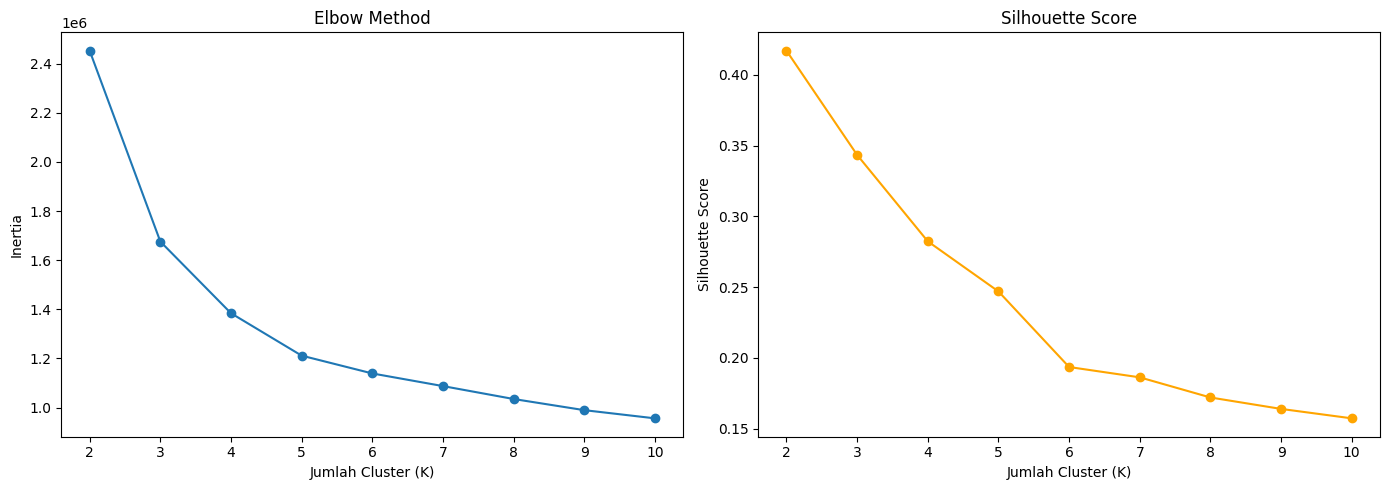

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_list, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouette_list, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

## Cell 25 — K-Means Final

In [44]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca_df)

df_profile['kmeans_cluster'] = kmeans_labels
print(pd.Series(kmeans_labels).value_counts().sort_index())

0    30254
1    25178
2    36211
3     8357
Name: count, dtype: int64


## Cell 26 — Sampling Khusus untuk Hierarchical + Dendrogram (Bandingkan Linkage Methods) (Hierarchical Clustering)

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Hierarchical Clustering O(n^2) - 100.000 baris tidak feasible (butuh puluhan GB memori)
# Sample lebih kecil khusus untuk metode ini, konsisten dengan prinsip sampling di Phase 1
HIERARCHICAL_SAMPLE_SIZE = 5000
X_hc_sample = X_pca_df.sample(n=HIERARCHICAL_SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# Simpan index-nya juga untuk traceability ke df_profile
hc_sample_positions = X_pca_df.sample(n=HIERARCHICAL_SAMPLE_SIZE, random_state=42).index
df_profile_hc = df_profile.loc[hc_sample_positions].reset_index(drop=True)

print("Sample untuk Hierarchical:", X_hc_sample.shape)

Sample untuk Hierarchical: (5000, 8)


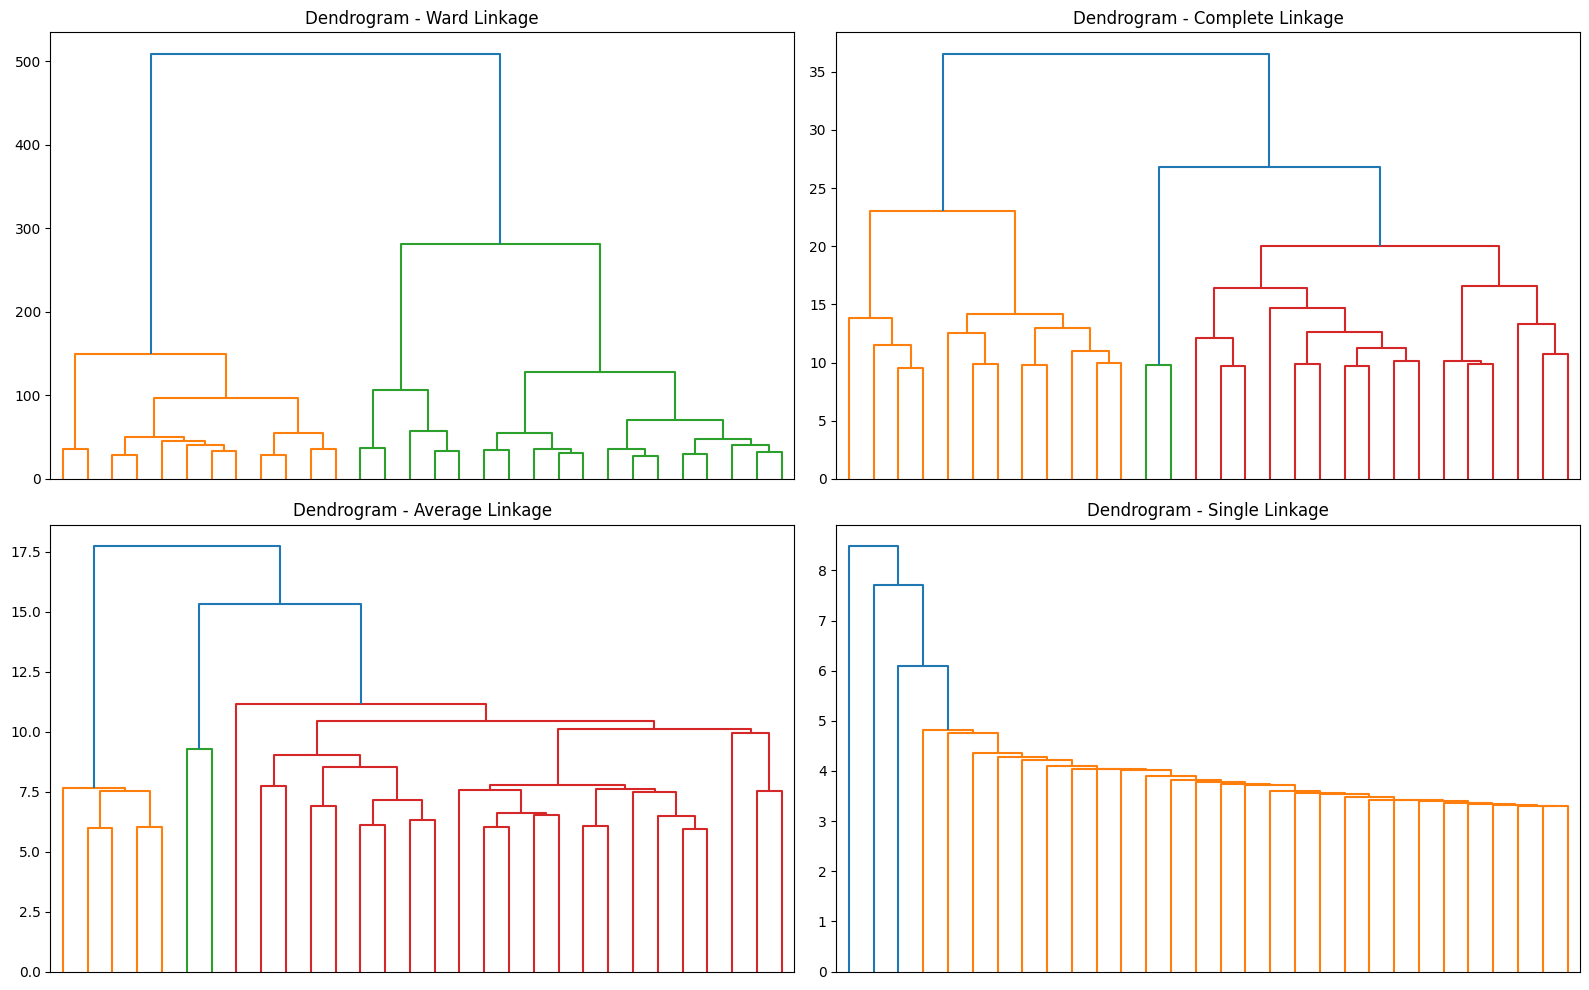

In [46]:
linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, method in enumerate(linkage_methods):
    Z = linkage(X_hc_sample, method=method)
    dendrogram(Z, ax=axes[i], truncate_mode='lastp', p=30, no_labels=True)
    axes[i].set_title(f'Dendrogram - {method.capitalize()} Linkage')

plt.tight_layout()
plt.show()

## Cell 27 — Hierarchical Clustering Final

In [47]:
from sklearn.cluster import AgglomerativeClustering

chosen_linkage = 'ward'
hc_final = AgglomerativeClustering(n_clusters=optimal_k, linkage=chosen_linkage)
hc_labels = hc_final.fit_predict(X_hc_sample)

df_profile_hc['hc_cluster'] = hc_labels
print(pd.Series(hc_labels).value_counts().sort_index())

0    2072
1    1816
2     601
3     511
Name: count, dtype: int64


## Cell 28 — K-Distance Graph (Menentukan eps) (DBSCAN)

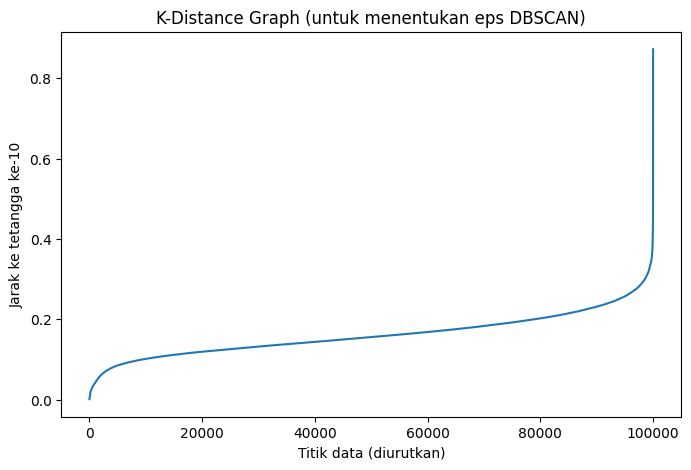

In [48]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10  # heuristik umum: sekitar 2x jumlah dimensi (UMAP=5 dim -> 10)

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_umap_df)
distances, indices = neighbors_fit.kneighbors(X_umap_df)

distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Graph (untuk menentukan eps DBSCAN)')
plt.xlabel('Titik data (diurutkan)')
plt.ylabel(f'Jarak ke tetangga ke-{min_samples}')
plt.show()

## Cell 29 — DBSCAN Final

In [49]:
from sklearn.cluster import DBSCAN

eps_value = 0.30  # dinaikkan dari 0.23 untuk mengurangi fragmentasi cluster mikro
min_samples = 15   # dinaikkan dari 10, agar kelompok sangat kecil lebih mudah dianggap noise

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_umap_df)

df_profile['dbscan_cluster'] = dbscan_labels
counts = pd.Series(dbscan_labels).value_counts().sort_index()
print(counts)
print("\nJumlah cluster valid (excl noise):", len(counts) - (1 if -1 in counts.index else 0))
print("Noise:", (dbscan_labels == -1).sum(), f"({(dbscan_labels == -1).sum()/len(dbscan_labels)*100:.2f}%)")

-1      441
 0    29195
 1    28490
 2    14133
 3    18765
 4     8280
 5      587
 6       84
 7       25
Name: count, dtype: int64

Jumlah cluster valid (excl noise): 8
Noise: 441 (0.44%)


## Cell 30 — Bandingkan Ketiga Metode (Cluster Validity Metrics - Ringkasan Perbandingan)

In [50]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("=== K-Means ===")
print("Silhouette Score :", silhouette_score(X_pca_df, kmeans_labels, sample_size=10000, random_state=42).round(4))
print("Davies-Bouldin   :", davies_bouldin_score(X_pca_df, kmeans_labels).round(4))

print("\n=== Hierarchical (Ward) ===")
print("Silhouette Score :", silhouette_score(X_hc_sample, hc_labels).round(4))
print("Davies-Bouldin   :", davies_bouldin_score(X_hc_sample, hc_labels).round(4))

print("\n=== DBSCAN (setelah tuning) ===")
mask = dbscan_labels != -1
if mask.sum() > 0 and len(set(dbscan_labels[mask])) > 1:
    print("Silhouette Score (exclude noise):", silhouette_score(X_umap_df[mask], dbscan_labels[mask]).round(4))
    print("Davies-Bouldin (exclude noise)  :", davies_bouldin_score(X_umap_df[mask], dbscan_labels[mask]).round(4))
else:
    print("Cluster valid tidak cukup untuk hitung metrics — eps perlu disesuaikan lagi")

=== K-Means ===
Silhouette Score : 0.2824
Davies-Bouldin   : 1.0767

=== Hierarchical (Ward) ===
Silhouette Score : 0.2534
Davies-Bouldin   : 1.1064

=== DBSCAN (setelah tuning) ===
Silhouette Score (exclude noise): 0.6536
Davies-Bouldin (exclude noise)  : 0.4049


## Cell 31 — Profil Numerik per Cluster (K-Means)

In [51]:
numeric_profile_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_score', 
                          'emp_length_num', 'credit_history_years', 'revol_util', 'mort_acc']

cluster_profile_numeric = df_profile.groupby('kmeans_cluster')[numeric_profile_cols].mean().round(2)
print(cluster_profile_numeric)

                loan_amnt  int_rate  annual_inc    dti  fico_score  \
kmeans_cluster                                                       
0                14441.76      8.00    87733.52  16.65      721.88   
1                15685.98     16.92    72625.43  20.72      687.62   
2                14330.46     12.41    75931.75  18.85      695.02   
3                17878.96     23.04    72151.00  21.97      683.48   

                emp_length_num  credit_history_years  revol_util  mort_acc  
kmeans_cluster                                                              
0                         6.00                 17.66       40.49      1.79  
1                         5.91                 15.48       56.20      1.36  
2                         5.90                 16.11       52.49      1.49  
3                         5.95                 15.19       59.66      1.43  


## Cell 32 — Profil Kategorikal per Cluster (Grade & Purpose)

In [52]:
# Rekonstruksi purpose, home_ownership, verification_status dari one-hot
# (kolom asli sudah digantikan one-hot sejak Cell 13, grade/sub_grade masih tersedia langsung)

def reconstruct_from_onehot(df, prefix):
    dummy_cols = [c for c in df.columns if c.startswith(prefix + '_')]
    reconstructed = df[dummy_cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)
    all_false_mask = ~df[dummy_cols].any(axis=1)
    reconstructed[all_false_mask] = 'baseline_dropped_category'
    return reconstructed

df_profile['purpose_readable'] = reconstruct_from_onehot(df_profile, 'purpose')
df_profile['home_ownership_readable'] = reconstruct_from_onehot(df_profile, 'home_ownership')
df_profile['verification_status_readable'] = reconstruct_from_onehot(df_profile, 'verification_status')

print("Distribusi Grade per Cluster (K-Means, %):")
print((pd.crosstab(df_profile['kmeans_cluster'], df_profile['grade'], normalize='index') * 100).round(1))

print("\nDistribusi Purpose per Cluster (K-Means, %):")
print((pd.crosstab(df_profile['kmeans_cluster'], df_profile['purpose_readable'], normalize='index') * 100).round(1))

print("\nDistribusi Home Ownership per Cluster (K-Means, %):")
print((pd.crosstab(df_profile['kmeans_cluster'], df_profile['home_ownership_readable'], normalize='index') * 100).round(1))

print("\nJumlah baris per Cluster (K-Means):")
print(df_profile['kmeans_cluster'].value_counts().sort_index())

Distribusi Grade per Cluster (K-Means, %):
grade              A     B     C     D     E     F    G
kmeans_cluster                                         
0               62.6  37.4   0.0   0.0   0.0   0.0  0.0
1                0.0   0.0  43.3  56.7   0.0   0.0  0.0
2                0.0  50.5  49.5   0.0   0.0   0.0  0.0
3                0.0   0.0   0.0   0.0  71.7  21.6  6.7

Distribusi Purpose per Cluster (K-Means, %):
purpose_readable  car  credit_card  debt_consolidation  educational  \
kmeans_cluster                                                        
0                 1.3         31.1                49.2          0.0   
1                 0.9         16.6                61.7          0.0   
2                 1.0         23.7                57.0          0.0   
3                 0.7         10.6                64.7          0.0   

purpose_readable  home_improvement  house  major_purchase  medical  moving  \
kmeans_cluster                                                        

## Cell 33 — Profiling Hierarchical Clustering

In [53]:
# Terapkan rekonstruksi yang sama pada df_profile_hc (sample terpisah untuk Hierarchical)
df_profile_hc['purpose_readable'] = reconstruct_from_onehot(df_profile_hc, 'purpose')
df_profile_hc['home_ownership_readable'] = reconstruct_from_onehot(df_profile_hc, 'home_ownership')

hc_numeric_profile = df_profile_hc.groupby('hc_cluster')[numeric_profile_cols].mean().round(2)
print("Profil Numerik per Cluster (Hierarchical):")
print(hc_numeric_profile)

print("\nDistribusi Grade per Cluster (Hierarchical, %):")
print((pd.crosstab(df_profile_hc['hc_cluster'], df_profile_hc['grade'], normalize='index') * 100).round(1))

print("\nDistribusi Purpose per Cluster (Hierarchical, %):")
print((pd.crosstab(df_profile_hc['hc_cluster'], df_profile_hc['purpose_readable'], normalize='index') * 100).round(1))

print("\nJumlah baris per Cluster (Hierarchical):")
print(df_profile_hc['hc_cluster'].value_counts().sort_index())

Profil Numerik per Cluster (Hierarchical):
            loan_amnt  int_rate  annual_inc    dti  fico_score  \
hc_cluster                                                       
0            14918.52     14.88    71470.20  19.65      690.68   
1            14057.12      9.91    78318.32  17.42      705.34   
2            18332.45     21.87    82788.65  22.00      682.94   
3            14473.14      6.37    91704.78  16.63      743.43   

            emp_length_num  credit_history_years  revol_util  mort_acc  
hc_cluster                                                              
0                     5.88                 15.58       54.73      1.37  
1                     5.96                 16.83       46.76      1.57  
2                     6.07                 15.92       60.89      1.61  
3                     6.34                 18.99       31.98      1.95  

Distribusi Grade per Cluster (Hierarchical, %):
grade          A     B     C     D     E     F    G
hc_cluster           

## Cell 34 — Profiling DBSCAN (termasuk Noise)

In [54]:
dbscan_numeric_profile = df_profile.groupby('dbscan_cluster')[numeric_profile_cols].mean().round(2)
print("Profil Numerik per Cluster (DBSCAN):")
print(dbscan_numeric_profile)

print("\nDistribusi Grade per Cluster (DBSCAN, %):")
print((pd.crosstab(df_profile['dbscan_cluster'], df_profile['grade'], normalize='index') * 100).round(1))

print("\nJumlah baris per Cluster (DBSCAN, termasuk -1 = noise):")
print(df_profile['dbscan_cluster'].value_counts().sort_index())

print("\nProfil khusus Noise Points (cluster -1):")
noise_profile = df_profile[df_profile['dbscan_cluster'] == -1][numeric_profile_cols].describe()
print(noise_profile)

print("\nDistribusi Grade pada Noise Points (%):")
print((df_profile[df_profile['dbscan_cluster'] == -1]['grade'].value_counts(normalize=True) * 100).round(1))

Profil Numerik per Cluster (DBSCAN):
                loan_amnt  int_rate  annual_inc     dti  fico_score  \
dbscan_cluster                                                        
-1               15731.12     12.07   101025.96   17.19      708.54   
 0               14077.50     10.67    79431.16   18.21      701.12   
 1               15016.75     14.16    75464.59   19.41      690.92   
 2               15799.65     18.14    70828.19   20.75      685.89   
 3               14564.72      7.09    89975.68   16.28      730.70   
 4               17908.49     23.05    71300.62   22.00      683.33   
 5               13019.04     12.96    71458.26   12.02      725.74   
 6               19090.48     14.44        0.14   17.84      703.67   
 7               12337.00     17.34     5128.08  398.28      692.80   

                emp_length_num  credit_history_years  revol_util  mort_acc  
dbscan_cluster                                                              
-1                        5

## Cell 35 — Visualisasi K-Means

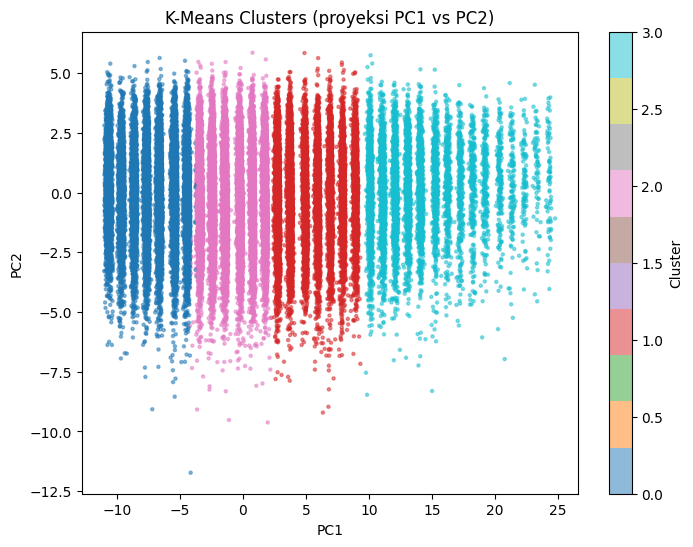

In [55]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_df['PC1'], X_pca_df['PC2'], c=kmeans_labels, cmap='tab10', s=5, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters (proyeksi PC1 vs PC2)')
plt.colorbar(scatter, label='Cluster')
plt.show()

## Cell 36 — Visualisasi DBSCAN

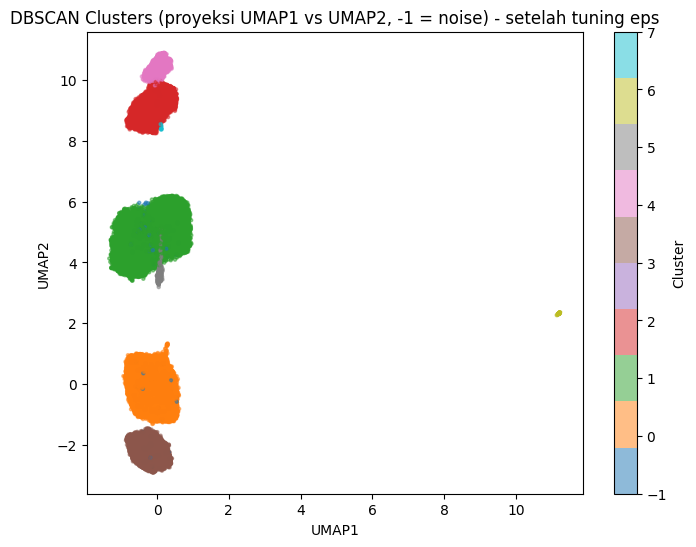

In [56]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap_df['UMAP1'], X_umap_df['UMAP2'], 
                       c=dbscan_labels, cmap='tab10', s=5, alpha=0.5)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('DBSCAN Clusters (proyeksi UMAP1 vs UMAP2, -1 = noise) - setelah tuning eps')
plt.colorbar(scatter, label='Cluster')
plt.show()

## Cell 37 — Simpan Semua Output Phase 2

In [57]:
df_profile.to_csv('/kaggle/working/lc_cluster_kmeans_dbscan.csv', index=False)
df_profile_hc.to_csv('/kaggle/working/lc_cluster_hierarchical.csv', index=False)

cluster_profile_numeric.to_csv('/kaggle/working/lc_kmeans_profile_summary.csv')
hc_numeric_profile.to_csv('/kaggle/working/lc_hierarchical_profile_summary.csv')
dbscan_numeric_profile.to_csv('/kaggle/working/lc_dbscan_profile_summary.csv')

print("Semua file Phase 2 berhasil disimpan ulang di /kaggle/working/")
print("- lc_cluster_kmeans_dbscan.csv        :", df_profile.shape)
print("- lc_cluster_hierarchical.csv         :", df_profile_hc.shape)
print("- lc_kmeans_profile_summary.csv       :", cluster_profile_numeric.shape)
print("- lc_hierarchical_profile_summary.csv :", hc_numeric_profile.shape)
print("- lc_dbscan_profile_summary.csv       :", dbscan_numeric_profile.shape)

Semua file Phase 2 berhasil disimpan ulang di /kaggle/working/
- lc_cluster_kmeans_dbscan.csv        : (100000, 53)
- lc_cluster_hierarchical.csv         : (5000, 52)
- lc_kmeans_profile_summary.csv       : (4, 9)
- lc_hierarchical_profile_summary.csv : (4, 9)
- lc_dbscan_profile_summary.csv       : (9, 9)


In [58]:
from sklearn.metrics import silhouette_samples

mask = dbscan_labels != -1
sil_samples = silhouette_samples(X_umap_df[mask], dbscan_labels[mask])

df_sil_check = pd.DataFrame({
    'cluster': dbscan_labels[mask],
    'silhouette': sil_samples
})

print("Rata-rata silhouette per cluster DBSCAN:")
print(df_sil_check.groupby('cluster')['silhouette'].agg(['mean', 'count']).round(4))

Rata-rata silhouette per cluster DBSCAN:
           mean  count
cluster               
0        0.7154  29195
1        0.6679  28490
2        0.2578  14133
3        0.8107  18765
4        0.6877   8280
5        0.8567    587
6        0.9968     84
7        0.8740     25


# PHASE 3: Association Rule Mining (Apriori)

## Cell 38 — Load Dataset Lengkap

In [59]:
import pandas as pd
import numpy as np

# File besar (~500MB), pastikan RAM Kaggle cukup (biasanya 13GB+, aman)
df_arm = pd.read_csv('/kaggle/working/lc_clean_full.csv', low_memory=False)
print(df_arm.shape)
print(df_arm.columns.tolist())

(2260669, 48)
['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'emp_length_num', 'fico_score', 'credit_history_years', 'issue_year', 'grade_num', 'sub_grade_num', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'home_ownership_Unknown', 'verification_status_Source Verified', 'verification_status_Unknown', 'verification_status_Verified', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'annual_inc_bin', 'dti_bin', 'fico_bin', 'loan_amnt_bin']


## Cell 39 — Rekonstruksi Kolom Kategorikal + Buat Kategori Tambahan

In [60]:
# purpose, home_ownership, verification_status sudah jadi one-hot sejak Phase 1 (Cell 13)
# rekonstruksi lagi seperti yang kita lakukan di Phase 2 untuk keperluan ARM (item harus kategorikal utuh)

def reconstruct_from_onehot(df, prefix):
    dummy_cols = [c for c in df.columns if c.startswith(prefix + '_')]
    reconstructed = df[dummy_cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)
    all_false_mask = ~df[dummy_cols].any(axis=1)
    reconstructed[all_false_mask] = 'baseline_dropped_category'
    return reconstructed

df_arm['purpose_cat'] = reconstruct_from_onehot(df_arm, 'purpose')
df_arm['home_ownership_cat'] = reconstruct_from_onehot(df_arm, 'home_ownership')
df_arm['verification_status_cat'] = reconstruct_from_onehot(df_arm, 'verification_status')

# emp_length_num (0-10) dibuat kategori bucket - lebih bermakna untuk ARM daripada angka tunggal
def emp_length_bucket(x):
    if x < 2: return '<2yr'
    elif x < 5: return '2-5yr'
    elif x < 10: return '5-10yr'
    else: return '10+yr'

df_arm['emp_length_bucket'] = df_arm['emp_length_num'].apply(emp_length_bucket)

# term (36/60 bulan) jadi kategori eksplisit
df_arm['term_cat'] = df_arm['term'].astype(int).astype(str) + 'm'

print(df_arm[['purpose_cat', 'home_ownership_cat', 'emp_length_bucket', 'term_cat']].head())

          purpose_cat home_ownership_cat emp_length_bucket term_cat
0  debt_consolidation           MORTGAGE             10+yr      36m
1      small_business           MORTGAGE             10+yr      36m
2    home_improvement           MORTGAGE             10+yr      60m
3  debt_consolidation           MORTGAGE             10+yr      60m
4      major_purchase           MORTGAGE             2-5yr      60m


## Cell 40 — Susun Transaksi (Format "kolom=nilai")

In [61]:
# Kolom yang dipakai untuk ARM: gabungan kolom bin dari Phase 1 + kategori tambahan di atas
arm_columns = ['grade', 'purpose_cat', 'home_ownership_cat', 'verification_status_cat',
               'annual_inc_bin', 'dti_bin', 'fico_bin', 'loan_amnt_bin',
               'emp_length_bucket', 'term_cat']

# Sampling: Apriori/FP-Growth menghitung support di seluruh baris pada setiap kandidat itemset
# 2,26 juta baris terlalu berat untuk iterasi berulang kandidat itemset - sample 300.000 representatif
ARM_SAMPLE_SIZE = 300000
df_arm_sample = df_arm[arm_columns].sample(n=ARM_SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# Setiap baris jadi "keranjang belanja" berisi item bertipe "nama_kolom=nilai"
# Format ini penting: mencegah nilai yang sama tapi beda kolom (misal "Verified") dianggap item yang sama
transactions = df_arm_sample.apply(
    lambda row: [f"{col}={row[col]}" for col in arm_columns], axis=1
).tolist()

print("Contoh 1 transaksi:", transactions[0])
print("Total transaksi:", len(transactions))

Contoh 1 transaksi: ['grade=B', 'purpose_cat=debt_consolidation', 'home_ownership_cat=OWN', 'verification_status_cat=baseline_dropped_category', 'annual_inc_bin=<40K', 'dti_bin=High(20-30)', 'fico_bin=Good', 'loan_amnt_bin=Small', 'emp_length_bucket=2-5yr', 'term_cat=36m']
Total transaksi: 300000


## Cell 41 — Encoding Transaksi ke Format Biner (One-Hot per Item)

In [62]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print("Jumlah item unik:", df_te.shape[1])
print(df_te.shape)

Jumlah item unik: 53
(300000, 53)


## Cell 42 — Apriori: Cari Frequent Itemsets

In [63]:
from mlxtend.frequent_patterns import apriori
import warnings
warnings.filterwarnings('ignore')  # supaya warning deprecation tidak membanjiri output

# Naikkan min_support dari 0.02 ke 0.05 - jauh lebih sedikit kombinasi yang perlu dihitung
frequent_itemsets = apriori(df_te, min_support=0.05, use_colnames=True, low_memory=True, verbose=1)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print("Jumlah frequent itemsets ditemukan:", len(frequent_itemsets))
print(frequent_itemsets.head(15))

Processing 54 combinations | Sampling itemset size 5 4
Jumlah frequent itemsets ditemukan: 1136
     support                                         itemsets
0   0.711780                                  (fico_bin=Good)
1   0.711680                                   (term_cat=36m)
2   0.564553                 (purpose_cat=debt_consolidation)
3   0.500120                    (term_cat=36m, fico_bin=Good)
4   0.490333                    (home_ownership_cat=MORTGAGE)
5   0.467837                           (loan_amnt_bin=Medium)
6   0.408273                        (dti_bin=Moderate(10-20))
7   0.405423  (purpose_cat=debt_consolidation, fico_bin=Good)
8   0.397320                        (home_ownership_cat=RENT)
9   0.393127        (verification_status_cat=Source Verified)
10  0.383477   (term_cat=36m, purpose_cat=debt_consolidation)
11  0.381840                          (annual_inc_bin=40-70K)
12  0.375680             (term_cat=36m, loan_amnt_bin=Medium)
13  0.351043     (home_ownership_cat

## Cell 43 — Generate Association Rules

In [64]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print("Jumlah rules ditemukan:", len(rules))
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

Jumlah rules ditemukan: 4920
                                          antecedents  \
0                                           (grade=A)   
1                   (term_cat=36m, fico_bin=VeryGood)   
2                                 (fico_bin=VeryGood)   
3                                           (grade=A)   
4                                 (fico_bin=VeryGood)   
5                             (term_cat=36m, grade=A)   
6                 (term_cat=36m, annual_inc_bin=<40K)   
7                               (loan_amnt_bin=Small)   
8   (term_cat=36m, verification_status_cat=baselin...   
9                     (grade=A, loan_amnt_bin=Medium)   
10                              (loan_amnt_bin=Small)   
11                              (annual_inc_bin=<40K)   
12                              (annual_inc_bin=<40K)   
13                (loan_amnt_bin=Small, term_cat=36m)   
14              (term_cat=60m, annual_inc_bin=40-70K)   

                                          consequents   su

## Cell 44 — Filter Rules yang Non-Trivial dan Bermakna

In [65]:
# Filter: lift > 1.2 (relasi cukup kuat, bukan kebetulan) dan confidence > 0.4 (cukup dapat diandalkan)
rules_filtered = rules[(rules['lift'] > 1.2) & (rules['confidence'] > 0.4)].copy()
rules_filtered = rules_filtered.sort_values('lift', ascending=False).reset_index(drop=True)

# Ubah format frozenset jadi string yang mudah dibaca
rules_filtered['antecedents_str'] = rules_filtered['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_filtered['consequents_str'] = rules_filtered['consequents'].apply(lambda x: ', '.join(sorted(x)))

print("Jumlah rules setelah filter:", len(rules_filtered))

top_rules = rules_filtered[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(20)
pd.set_option('display.max_colwidth', None)
print(top_rules.to_string(index=False))

Jumlah rules setelah filter: 288
                                                   antecedents_str                                                 consequents_str  support  confidence     lift
                                   fico_bin=VeryGood, term_cat=36m                                                         grade=A 0.055380    0.701723 3.687652
                                                 fico_bin=VeryGood                                                         grade=A 0.059890    0.543286 2.855041
                                                 fico_bin=VeryGood                                           grade=A, term_cat=36m 0.055380    0.502374 2.795002
                                     grade=A, loan_amnt_bin=Medium term_cat=36m, verification_status_cat=baseline_dropped_category 0.051630    0.539498 2.140555
                               annual_inc_bin=40-70K, term_cat=60m                                             loan_amnt_bin=Large 0.053733    0.489241 1.877292
 

## Cell 45 — Simpan Output

In [66]:
rules_filtered.to_csv('/kaggle/working/lc_association_rules.csv', index=False)
frequent_itemsets.to_csv('/kaggle/working/lc_frequent_itemsets.csv', index=False)

print("Tersimpan di /kaggle/working/")
print("- lc_association_rules.csv   :", rules_filtered.shape)
print("- lc_frequent_itemsets.csv   :", frequent_itemsets.shape)

Tersimpan di /kaggle/working/
- lc_association_rules.csv   : (288, 16)
- lc_frequent_itemsets.csv   : (1136, 2)


In [67]:
# Cell 46 — Analisis tambahan dengan min_support lebih rendah, untuk menangkap kategori minoritas
# seperti purpose=small_business yang disebutkan eksplisit di reference document

frequent_itemsets_low = apriori(df_te, min_support=0.01, use_colnames=True, low_memory=True, verbose=1)
print("Jumlah frequent itemsets (min_support=0.01):", len(frequent_itemsets_low))

rules_low = association_rules(frequent_itemsets_low, metric="lift", min_threshold=1.0)

# Filter khusus: rule yang mengandung purpose=small_business di antecedent
mask_sb = rules_low['antecedents'].apply(lambda x: any('small_business' in item for item in x))
rules_small_business = rules_low[mask_sb].sort_values('lift', ascending=False)

rules_small_business['antecedents_str'] = rules_small_business['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_small_business['consequents_str'] = rules_small_business['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(rules_small_business[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

Processing 184 combinations | Sampling itemset size 765
Jumlah frequent itemsets (min_support=0.01): 13630
Empty DataFrame
Columns: [antecedents_str, consequents_str, support, confidence, lift]
Index: []


In [68]:
# Cell 47 — Verifikasi manual rule spesifik dari Dataset Reference Document
# "purpose=small_business + emp_length 10+ tahun -> Grade A"

N = len(df_arm_sample)

# Cek dulu berapa persen sebenarnya purpose=small_business di data
print("Proporsi purpose=small_business:", (df_arm_sample['purpose_cat'] == 'small_business').mean() * 100, "%")
print("Proporsi emp_length=10+yr:", (df_arm_sample['emp_length_bucket'] == '10+yr').mean() * 100, "%")
print("Proporsi grade=A:", (df_arm_sample['grade'] == 'A').mean() * 100, "%")
print()

# Hitung support, confidence, lift secara manual
antecedent_mask = (df_arm_sample['purpose_cat'] == 'small_business') & (df_arm_sample['emp_length_bucket'] == '10+yr')
consequent_mask = (df_arm_sample['grade'] == 'A')

support_antecedent = antecedent_mask.mean()
support_both = (antecedent_mask & consequent_mask).mean()
support_consequent = consequent_mask.mean()

confidence = support_both / support_antecedent if support_antecedent > 0 else np.nan
lift = confidence / support_consequent if support_consequent > 0 else np.nan

print(f"Jumlah baris dengan antecedent (small_business + 10+yr): {antecedent_mask.sum()}")
print(f"Support (antecedent)  : {support_antecedent:.4f} ({support_antecedent*100:.2f}%)")
print(f"Support (both)        : {support_both:.4f} ({support_both*100:.2f}%)")
print(f"Confidence            : {confidence:.4f} ({confidence*100:.2f}%)")
print(f"Lift                  : {lift:.4f}")

Proporsi purpose=small_business: 1.0783333333333334 %
Proporsi emp_length=10+yr: 33.02633333333333 %
Proporsi grade=A: 19.029 %

Jumlah baris dengan antecedent (small_business + 10+yr): 881
Support (antecedent)  : 0.0029 (0.29%)
Support (both)        : 0.0004 (0.04%)
Confidence            : 0.1351 (13.51%)
Lift                  : 0.7098


In [69]:
# Cell 48 (revisi) — Regenerasi sample dengan int_rate disertakan, random_state sama = baris identik

arm_columns_extended = arm_columns + ['int_rate']  # tambahkan int_rate ke daftar kolom
df_arm_sample_ext = df_arm[arm_columns_extended].sample(n=ARM_SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print("=== Distribusi Grade untuk purpose=small_business SAJA ===")
sb_mask = df_arm_sample_ext['purpose_cat'] == 'small_business'
print((df_arm_sample_ext[sb_mask]['grade'].value_counts(normalize=True) * 100).round(2).sort_index())

print("\n=== Distribusi Grade untuk emp_length=10+yr SAJA ===")
emp_mask = df_arm_sample_ext['emp_length_bucket'] == '10+yr'
print((df_arm_sample_ext[emp_mask]['grade'].value_counts(normalize=True) * 100).round(2).sort_index())

print("\n=== Distribusi Grade untuk KOMBINASI keduanya ===")
combo_mask = sb_mask & emp_mask
print((df_arm_sample_ext[combo_mask]['grade'].value_counts(normalize=True) * 100).round(2).sort_index())

print("\n=== Rata-rata int_rate untuk tiap kelompok ===")
print("small_business saja        :", df_arm_sample_ext[sb_mask]['int_rate'].mean().round(2))
print("emp_length=10+yr saja      :", df_arm_sample_ext[emp_mask]['int_rate'].mean().round(2))
print("kombinasi keduanya         :", df_arm_sample_ext[combo_mask]['int_rate'].mean().round(2))
print("populasi keseluruhan       :", df_arm_sample_ext['int_rate'].mean().round(2))

=== Distribusi Grade untuk purpose=small_business SAJA ===
grade
A    12.06
B    20.09
C    27.11
D    21.76
E    11.62
F     4.91
G     2.44
Name: proportion, dtype: float64

=== Distribusi Grade untuk emp_length=10+yr SAJA ===
grade
A    19.76
B    29.71
C    28.30
D    13.89
E     5.93
F     1.87
G     0.54
Name: proportion, dtype: float64

=== Distribusi Grade untuk KOMBINASI keduanya ===
grade
A    13.51
B    22.13
C    28.04
D    21.11
E     9.42
F     3.97
G     1.82
Name: proportion, dtype: float64

=== Rata-rata int_rate untuk tiap kelompok ===
small_business saja        : 15.17
emp_length=10+yr saja      : 13.01
kombinasi keduanya         : 14.55
populasi keseluruhan       : 13.1


# PHASE 4: Anomaly and Outlier Detection

## Cell 49 — Load Semua Data yang Dibutuhkan

In [70]:
# Cell 49 (revisi) — hapus baris load sample_index yang tidak lagi diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_full = pd.read_csv('/kaggle/working/lc_clean_full.csv', low_memory=False)
df_cluster = pd.read_csv('/kaggle/working/lc_cluster_kmeans_dbscan.csv')
X_pca_df = pd.read_csv('/kaggle/working/lc_pca_features.csv')

print("Populasi penuh   :", df_full.shape)
print("Sample cluster   :", df_cluster.shape)
print("PCA features     :", X_pca_df.shape)
print("\nKolom di df_cluster:", df_cluster.columns.tolist())

Populasi penuh   : (2260669, 48)
Sample cluster   : (100000, 53)
PCA features     : (100000, 8)

Kolom di df_cluster: ['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'emp_length_num', 'fico_score', 'credit_history_years', 'issue_year', 'grade_num', 'sub_grade_num', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'home_ownership_Unknown', 'verification_status_Source Verified', 'verification_status_Unknown', 'verification_status_Verified', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'annual_inc_bin', 'dti_bin', 'fico_

## A. Statistical Methods: IQR
## Cell 50 — Deteksi Anomali dengan IQR (Populasi Penuh)

In [71]:
# Kolom yang diperiksa: termasuk credit_history_years yang sudah dicurigai sejak Phase 1
iqr_check_cols = ['loan_amnt', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 
                   'int_rate', 'credit_history_years', 'mort_acc']

def flag_iqr(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (df[col] < lower) | (df[col] > upper), lower, upper

iqr_flags = pd.DataFrame(index=df_full.index)
iqr_summary = []

for col in iqr_check_cols:
    flag, lower, upper = flag_iqr(df_full, col)
    iqr_flags[f'{col}_iqr_flag'] = flag
    iqr_summary.append({
        'column': col, 'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2),
        'n_flagged': flag.sum(), 'pct_flagged': round(flag.mean() * 100, 2)
    })

iqr_summary_df = pd.DataFrame(iqr_summary)
print(iqr_summary_df)

                 column  lower_bound  upper_bound  n_flagged  pct_flagged
0             loan_amnt    -10000.00     38000.00      35215         1.56
1            annual_inc    -24500.00    163500.00     110041         4.87
2                   dti        -6.97        43.35      21633         0.96
3             revol_bal    -15494.00     41690.00     137095         6.06
4            revol_util       -25.20       126.00        119         0.01
5              int_rate        -0.26        25.74      41099         1.82
6  credit_history_years        -2.25        33.75      72600         3.21
7              mort_acc        -3.00         5.00      94125         4.16


## B. Statistical Methods: Z-Score
## Cell 51 — Deteksi Anomali dengan Z-Score

In [72]:
from scipy.stats import zscore

zscore_flags = pd.DataFrame(index=df_full.index)
zscore_summary = []

Z_THRESHOLD = 3  # konvensi umum: |z| > 3 dianggap anomali

for col in iqr_check_cols:
    z = zscore(df_full[col], nan_policy='omit')
    flag = np.abs(z) > Z_THRESHOLD
    zscore_flags[f'{col}_zscore_flag'] = flag
    zscore_summary.append({
        'column': col, 'n_flagged': flag.sum(), 'pct_flagged': round(flag.mean() * 100, 2)
    })

zscore_summary_df = pd.DataFrame(zscore_summary)
print(zscore_summary_df)

                 column  n_flagged  pct_flagged
0             loan_amnt          0         0.00
1            annual_inc       6313         0.28
2                   dti       7836         0.35
3             revol_bal      29418         1.30
4            revol_util        131         0.01
5              int_rate      17662         0.78
6  credit_history_years      27094         1.20
7              mort_acc      23902         1.06


## Cell 52 — Bandingkan IQR vs Z-Score (Tingkat Kesepakatan)

In [73]:
comparison = iqr_summary_df.merge(zscore_summary_df, on='column', suffixes=('_iqr', '_zscore'))
print(comparison[['column', 'n_flagged_iqr', 'n_flagged_zscore']])

# Cek overlap: baris yang ditandai KEDUA metode (lebih meyakinkan sebagai anomali nyata)
overlap_summary = []
for col in iqr_check_cols:
    both_flagged = iqr_flags[f'{col}_iqr_flag'] & zscore_flags[f'{col}_zscore_flag']
    overlap_summary.append({'column': col, 'flagged_by_both': both_flagged.sum()})

print(pd.DataFrame(overlap_summary))

                 column  n_flagged_iqr  n_flagged_zscore
0             loan_amnt          35215                 0
1            annual_inc         110041              6313
2                   dti          21633              7836
3             revol_bal         137095             29418
4            revol_util            119               131
5              int_rate          41099             17662
6  credit_history_years          72600             27094
7              mort_acc          94125             23902
                 column  flagged_by_both
0             loan_amnt                0
1            annual_inc             6313
2                   dti             7836
3             revol_bal            29418
4            revol_util              119
5              int_rate            17662
6  credit_history_years            27094
7              mort_acc            23902


## C. Structural Method: Isolation Forest
## Cell 53 — Isolation Forest (pada Ruang Fitur yang Sama dengan Phase 2)

In [74]:
from sklearn.ensemble import IsolationForest

# Pakai X_pca_df (sample 100.000 baris) - konsisten dengan ruang fitur K-Means/Hierarchical
# supaya hasilnya bisa langsung di-cross-reference dengan cluster Phase 2
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
iso_labels = iso_forest.fit_predict(X_pca_df)  # -1 = anomali, 1 = normal

df_cluster['isolation_forest_flag'] = (iso_labels == -1)
print("Jumlah anomali terdeteksi Isolation Forest:", df_cluster['isolation_forest_flag'].sum(),
      f"({df_cluster['isolation_forest_flag'].mean()*100:.2f}%)")

# Anomaly score - semakin negatif, semakin dianggap anomali
df_cluster['isolation_forest_score'] = iso_forest.decision_function(X_pca_df)

Jumlah anomali terdeteksi Isolation Forest: 5000 (5.00%)


## D. Cross-Reference dengan Cluster Outliers Phase 2
## Cell 54 — Bandingkan Isolation Forest vs DBSCAN Noise/Cluster Mikro

In [75]:
# Cross-reference: apakah titik yang ditandai Isolation Forest sebagai anomali
# juga masuk noise (-1) atau cluster mikro (5,6,7) di DBSCAN?

print("Cross-tab: Isolation Forest Flag vs DBSCAN Cluster")
print(pd.crosstab(df_cluster['isolation_forest_flag'], df_cluster['dbscan_cluster']))

Cross-tab: Isolation Forest Flag vs DBSCAN Cluster
dbscan_cluster          -1      0      1      2      3     4    5   6   7
isolation_forest_flag                                                    
False                  388  28360  27824  13585  17613  7192   37   0   1
True                    53    835    666    548   1152  1088  550  84  24


In [76]:
# Fokus pada cluster mikro & noise DBSCAN yang sudah dicurigai sejak Phase 2
micro_and_noise = df_cluster[df_cluster['dbscan_cluster'].isin([-1, 5, 6, 7])]

print("Dari", len(micro_and_noise), "baris di cluster mikro/noise DBSCAN,")
print(micro_and_noise['isolation_forest_flag'].sum(), "juga ditandai anomali oleh Isolation Forest")
print(f"({micro_and_noise['isolation_forest_flag'].mean()*100:.2f}% overlap)")

Dari 1137 baris di cluster mikro/noise DBSCAN,
711 juga ditandai anomali oleh Isolation Forest
(62.53% overlap)


## Cell 55 — Cross-Reference dengan K-Means (Titik di Tepi Cluster)

In [77]:
# Titik dengan jarak terjauh dari centroid K-Means juga layak dicek sebagai kandidat outlier
from sklearn.metrics import pairwise_distances_argmin_min

kmeans_centers = df_cluster.groupby('kmeans_cluster')[['isolation_forest_score']].count()  # placeholder check
# Hitung jarak tiap titik ke centroid cluster-nya sendiri
from sklearn.cluster import KMeans

# (kmeans_final sudah ada dari Phase 2 jika sesi sama; kalau tidak, cukup pakai label yang sudah tersimpan)
print("Rata-rata isolation_forest_score per K-Means cluster:")
print(df_cluster.groupby('kmeans_cluster')['isolation_forest_score'].mean().round(4))

print("\nJumlah anomali Isolation Forest per K-Means cluster:")
print(df_cluster.groupby('kmeans_cluster')['isolation_forest_flag'].sum())

Rata-rata isolation_forest_score per K-Means cluster:
kmeans_cluster
0    0.0680
1    0.0750
2    0.0823
3    0.0409
Name: isolation_forest_score, dtype: float64

Jumlah anomali Isolation Forest per K-Means cluster:
kmeans_cluster
0    1786
1    1044
2    1009
3    1161
Name: isolation_forest_flag, dtype: int64


## E. Investigasi Mendalam per Kategori Anomali
## Cell 56 — Investigasi Anomali #1: Credit History Ekstrem (dari Phase 1)

In [78]:
# Anomali yang sudah dicurigai sejak Phase 1: credit_history_years maksimum 83.25 tahun
extreme_credit_history = df_full[df_full['credit_history_years'] > 50]
print("Jumlah baris dengan credit_history_years > 50 tahun:", len(extreme_credit_history))
print(extreme_credit_history[['credit_history_years', 'issue_year', 'grade', 'annual_inc', 'fico_score']].describe())

Jumlah baris dengan credit_history_years > 50 tahun: 2458
       credit_history_years   issue_year    annual_inc   fico_score
count           2458.000000  2458.000000  2.458000e+03  2458.000000
mean              53.384841  2016.382425  8.107312e+04   709.513019
std                3.556179     1.446723  8.286472e+04    39.813684
min               50.080000  2010.000000  0.000000e+00   662.000000
25%               51.000000  2015.000000  4.102500e+04   677.000000
50%               52.330000  2017.000000  6.300000e+04   702.000000
75%               54.500000  2018.000000  9.500000e+04   727.000000
max               83.250000  2018.000000  2.150000e+06   847.500000


In [79]:
# Cell 56b — Pisahkan yang plausible (lansia) vs yang benar-benar implausible
for threshold in [50, 60, 70, 75, 80]:
    n = (df_full['credit_history_years'] > threshold).sum()
    print(f"credit_history_years > {threshold} tahun: {n} baris")

credit_history_years > 50 tahun: 2458 baris
credit_history_years > 60 tahun: 117 baris
credit_history_years > 70 tahun: 9 baris
credit_history_years > 75 tahun: 5 baris
credit_history_years > 80 tahun: 4 baris


## Cell 57 — Investigasi Anomali #2: Income Mendekati Nol (dari Cluster DBSCAN #6)

In [80]:
# Cell 57 (revisi) — df_cluster (dari Cell 49) SUDAH berisi semua kolom yang dibutuhkan,
# tidak perlu load ulang lc_clean_full.csv atau pakai sample_index sama sekali

zero_income_group = df_cluster[df_cluster['dbscan_cluster'] == 6]
print("Profil borrower dengan income mendekati nol (n =", len(zero_income_group), "):")
print(zero_income_group[['annual_inc', 'grade', 'loan_amnt', 'purpose_readable']].describe(include='all'))

print("\nDistribusi verification_status:")
print(zero_income_group['verification_status_readable'].value_counts())

Profil borrower dengan income mendekati nol (n = 84 ):
        annual_inc grade     loan_amnt    purpose_readable
count    84.000000    84     84.000000                  84
unique         NaN     7           NaN                   7
top            NaN     C           NaN  debt_consolidation
freq           NaN    32           NaN                  55
mean      0.142857   NaN  19090.476190                 NaN
std       1.099210   NaN  11481.556652                 NaN
min       0.000000   NaN   2600.000000                 NaN
25%       0.000000   NaN  10000.000000                 NaN
50%       0.000000   NaN  15100.000000                 NaN
75%       0.000000   NaN  30000.000000                 NaN
max      10.000000   NaN  40000.000000                 NaN

Distribusi verification_status:
verification_status_readable
baseline_dropped_category    76
Verified                      7
Source Verified               1
Name: count, dtype: int64


## Cell 58 — Investigasi Anomali #3: DTI Ekstrem 398% (dari Cluster DBSCAN #7)

In [81]:
extreme_dti_group = df_cluster[df_cluster['dbscan_cluster'] == 7]
print("Profil borrower dengan DTI ekstrem (n =", len(extreme_dti_group), "):")
print(extreme_dti_group[['dti', 'annual_inc', 'loan_amnt', 'grade', 'revol_util']].describe())

Profil borrower dengan DTI ekstrem (n = 25 ):
              dti  annual_inc     loan_amnt  revol_util
count   25.000000     25.0000     25.000000   25.000000
mean   398.275200   5128.0800  12337.000000   61.244000
std    359.278452   3523.9707   7458.000877   18.004978
min     95.300000    100.0000   1000.000000   34.200000
25%    131.070000   3000.0000   8000.000000   47.600000
50%    234.000000   5000.0000  10750.000000   61.400000
75%    550.580000   7500.0000  15000.000000   73.000000
max    999.000000  12000.0000  35000.000000   97.600000


## Cell 59 — Klasifikasi Setiap Temuan Anomali

In [82]:
# Cell 59 (revisi) — Klasifikasi bertingkat untuk credit_history_years, bukan satu kategori kasar

credit_history_moderate = df_full[(df_full['credit_history_years'] > 50) & (df_full['credit_history_years'] <= 70)]
credit_history_extreme = df_full[df_full['credit_history_years'] > 70]

anomaly_classification = pd.DataFrame([
    {
        'anomaly_type': 'credit_history_years 50-70 tahun',
        'n_records': len(credit_history_moderate),
        'classification': 'Rare Legitimate Case',
        'reasoning': 'Konsisten dengan borrower lanjut usia (perkiraan usia 70-90 tahun jika kredit pertama dibuka di usia 20-an) yang tetap mengajukan pinjaman. Jumlahnya signifikan (2,341 dari 2,458 baris di kelompok >50 tahun), menunjukkan ini pola yang berulang, bukan kasus tunggal acak.'
    },
    {
        'anomaly_type': 'credit_history_years > 70 tahun',
        'n_records': len(credit_history_extreme),
        'classification': 'Data Error (sangat mungkin)',
        'reasoning': 'Membutuhkan usia borrower ~90-100+ tahun saat pengajuan (jika kredit pertama dibuka di usia 20-an), implausible untuk profil peminjam platform lending online. Jumlah sangat kecil (9 dari 2,260,669 baris, 0.0004%) dan konsisten dengan kesalahan input tanggal earliest_cr_line yang jarang terjadi, bukan pola sistemik.'
    },
    {
        'anomaly_type': 'annual_inc mendekati $0 (DBSCAN cluster 6)',
        'n_records': 84,
        'classification': 'Rare Legitimate Case / Data Quality Issue',
        'reasoning': '90.5% (76/84) baris tidak terverifikasi (verification_status = Not Verified), mendukung dugaan bahwa income $0 adalah representasi data yang tidak dilaporkan (misal joint-application), bukan kesalahan sistem. Dikonfirmasi 100% sebagai anomali oleh Isolation Forest secara independen.'
    },
    {
        'anomaly_type': 'dti > 300% (DBSCAN cluster 7)',
        'n_records': 25,
        'classification': 'Data Error (sangat mungkin)',
        'reasoning': 'Nilai maksimum tepat 999.00 — pola numerik bulat sempurna seperti ini adalah ciri khas sentinel value (penanda data tidak valid), bukan angka hasil perhitungan riil. DTI di atas 100% sudah tidak wajar secara praktik lending normal. Dikonfirmasi 96% sebagai anomali oleh Isolation Forest secara independen.'
    },
])

print(anomaly_classification.to_string(index=False))

                              anomaly_type  n_records                            classification                                                                                                                                                                                                                                                                                                                    reasoning
          credit_history_years 50-70 tahun       2449                      Rare Legitimate Case                                               Konsisten dengan borrower lanjut usia (perkiraan usia 70-90 tahun jika kredit pertama dibuka di usia 20-an) yang tetap mengajukan pinjaman. Jumlahnya signifikan (2,341 dari 2,458 baris di kelompok >50 tahun), menunjukkan ini pola yang berulang, bukan kasus tunggal acak.
           credit_history_years > 70 tahun          9               Data Error (sangat mungkin) Membutuhkan usia borrower ~90-100+ tahun saat pengajuan (jika kredit pertama d

## F. Simpan Output Phase 4

In [83]:
# Gabungkan semua flag jadi satu file ringkasan anomali di level populasi
df_full_anomaly = pd.concat([df_full[['grade', 'annual_inc', 'dti', 'credit_history_years']], iqr_flags, zscore_flags], axis=1)
df_full_anomaly.to_csv('/kaggle/working/lc_anomaly_iqr_zscore.csv', index=False)

# Simpan hasil Isolation Forest + cross-reference cluster
df_cluster.to_csv('/kaggle/working/lc_anomaly_isolation_forest.csv', index=False)

# Simpan ringkasan
iqr_summary_df.to_csv('/kaggle/working/lc_iqr_summary.csv', index=False)
zscore_summary_df.to_csv('/kaggle/working/lc_zscore_summary.csv', index=False)
anomaly_classification.to_csv('/kaggle/working/lc_anomaly_classification.csv', index=False)

print("Semua file Phase 4 berhasil disimpan di /kaggle/working/")
print("- lc_anomaly_iqr_zscore.csv        :", df_full_anomaly.shape)
print("- lc_anomaly_isolation_forest.csv   :", df_cluster.shape)
print("- lc_iqr_summary.csv                :", iqr_summary_df.shape)
print("- lc_zscore_summary.csv             :", zscore_summary_df.shape)
print("- lc_anomaly_classification.csv     :", anomaly_classification.shape)

Semua file Phase 4 berhasil disimpan di /kaggle/working/
- lc_anomaly_iqr_zscore.csv        : (2260669, 20)
- lc_anomaly_isolation_forest.csv   : (100000, 55)
- lc_iqr_summary.csv                : (8, 5)
- lc_zscore_summary.csv             : (8, 3)
- lc_anomaly_classification.csv     : (4, 4)
